## Sentiment Analysis using a Bidirectional LSTM

Sentiment analysis is a useful way for understanding the prevailing sentiment in text. The internet today is a major source of textual data ranging from user reviews on online stores to articles or other long form content. It can be incredibly time-saving and efficient, especially for longer texts, to summarize and categorize data based on its inherent sentiment. This project walks through how to build a sentiment classifier using an LSTM (Long Short-Term Memory) architecture—a specialized RNN architecture for parsing long text sequences without losing valuable information.  
LSTMs, like other recurrent networks, process text one token at a time. However, LSTMs can capture word relationships over longer ranges by considering tokens both before and after the current time step. This allows them to better capture word meaning and context. Bidirectional LSTMs are specifically built for this purpose. To train the model, we use a collection of IMDB movie reviews[1](https://ai.stanford.edu/%7Eamaas/data/sentiment/).

### Overview

The model architecture for our binary sentiment analysis task will implement a Bi-directional LSTM with a trainable embedding layer that will ultimately score incoming text on a scale of 0 (most negative) to 1 (most positive). The token embeddings enable the model to build an internal representation of word meanings. These will be trained from scratch along with the weights for the LSTM architecture. 
Personally, sentiment analysis has been a huge area of interest of mine. I am excited to explore how to teach machines to process and classify text at scale. Let's walk through our model implementation.

### Model Implementation

For the model architecture, we will be using two components:  
1. A trainable Embedding Layer which represents the training tokens via fixed-length vectors.
2. LSTM model with 32 layers each of forward and backward units.

Additionally, dropout layers and a dense layer were added to improve learning efficiency and scoring.

To begin, I will load the modules and libraries. These are used to process text and implement the model architecture.

In [1]:
# import dependencies and libraries
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

### Pre-processing

#### Loading the Dataset

The IMDB dataset has been carefully annotated and comes pre-tokenized (i.e., the words in the reviews have been converted to integers). Thus, each review is essentially a list of numerals separated by commas. The dataset contains 50,000 reviews split evenly between the training and test set. Each review is labelled either _positive_ (label: 1) or  _negative_ (label: 0).

In [23]:
# load data (limiting to top 10,000 words)
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words= vocab_size)

Now for some quick sanity checks...

In [24]:
# check distinct classes in training set
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(12500), np.int64(1): np.int64(12500)}


It is perfectly balanced; as such, we are less likely to get biased results.

In [25]:
# check sample length
print(f"The length of the training sample is: {len(X_train)}")
print(f"The length of the test sample is: {len(X_test)}")

The length of the training sample is: 25000
The length of the test sample is: 25000


The IMDB model already comes with tokenized integer IDs for the words in the review. To get the original review, the custom function below can return the words using the word-to-index mapping, a lookup table that maps integers to their respective words. This attribute comes pre-loaded with the imdb module and can be accessed using the _imdb.get_word_index_ method.

In [27]:
# snippet of the first movie review
print(decode_review(X_train[0][:50]))

<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved


#### Padding

For optimal training, it is recommended to format the training corpus consistently. LSTMs require input data to be of a standardized length. To achieve that I evaluated the sentence length distribution to identify an optimal length.

In [28]:
# calculate sequence lengths (token count per sentence)
sequence_lengths = [len(seq) for seq in X_train]

# convert sequence lengths to 50th, 70th, and 90th percentiles
percentiles = np.percentile(sequence_lengths, [50, 70, 80, 90, 99])

print(f"50th Percentile (Median): {percentiles[0]:.0f}")
print(f"70th Percentile:          {percentiles[1]:.0f}")
print(f"80th Percentile:          {percentiles[2]:.0f}")
print(f"90th Percentile:          {percentiles[3]:.0f}")
print(f"99th Percentile:          {percentiles[4]:.0f}")

50th Percentile (Median): 178
70th Percentile:          257
80th Percentile:          331
90th Percentile:          467
99th Percentile:          926


From the above, a sequence length of 250 meaningfully covers a large majority of the training samples without overloading the model with excessive padding tokens.

In [29]:
# padding the training data- LSTMs require input data to be of uniform length
seq_length = 250
X_train_pad = pad_sequences(X_train, maxlen=seq_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test, maxlen=seq_length, padding='post', truncating='post')

# Re-confirming the sequence length
X_train_pad.shape

(25000, 250)

### Training and Evaluating the Model Architecture

In [30]:
# build embedding layer
embed_dim = 128
embed_layer = layers.Embedding(input_dim= vocab_size, output_dim= embed_dim)

# build model architecture
model = models.Sequential([
    embed_layer,
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid'),
    ])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

es_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

Now that the model architecture has been defined, we can begin training

In [31]:
# commence training on our corpus
history = model.fit(
    X_train_pad,
    y_train,
    validation_split= 0.2,
    epochs=10,
    batch_size=128,
    callbacks= [es_callback]
)

model.summary()

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 131s 799ms/step - accuracy: 0.7260 - loss: 0.5355 - val_accuracy: 0.8080 - val_loss: 0.4395
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 118s 751ms/step - accuracy: 0.8753 - loss: 0.3242 - val_accuracy: 0.8564 - val_loss: 0.4453
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 117s 745ms/step - accuracy: 0.9045 - loss: 0.2555 - val_accuracy: 0.8620 - val_loss: 0.3465
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 130s 827ms/step - accuracy: 0.9334 - loss: 0.1885 - val_accuracy: 0.8540 - val_loss: 0.3596
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 122s 779ms/step - accuracy: 0.9490 - loss: 0.1481 - val_accuracy: 0.8314 - val_loss: 0.3925
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 116s 739ms/step - accuracy: 0.9597 - loss: 0.1181 - val_accuracy: 0.8580 - val_loss: 0.5235


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 250, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,148,933 (15.83 MB)

 Trainable params: 1,382,977 (5.28 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,765,956 (10.55 MB)

In [32]:
results = model.evaluate(X_test_pad, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step - accuracy: 0.8387 - loss: 0.3836


In [33]:
# 1. testing the model
y_pred_prob = model.predict(X_test_pad)

782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step


In [34]:
# convert continuous probabilities into 0 or 1 integers
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# pass the discrete predictions (y_pred) to the classification_report
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.81      0.88      0.85     12500
    Positive       0.87      0.79      0.83     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



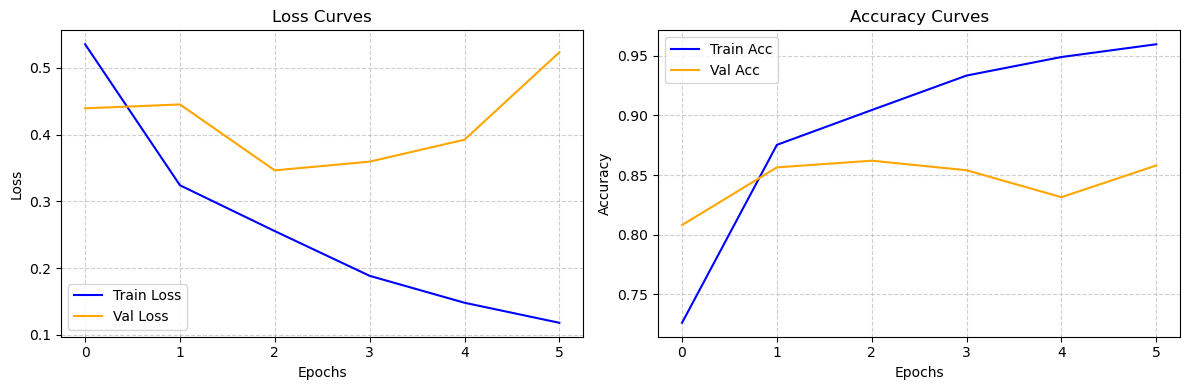

In [36]:
# Plotting loss and accuracy curves
plt.figure(figsize=(12, 4))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Acc', color='orange')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Model Prediction

Now we will build a function to predict text and deliver the model's verdict along with the score. A point to note is that since the text was trained on movie reviews, it is optimized for text that is focused on movies, plays or other similar content.  
In addition, it is better to feed text that has been trained on longer sequences.

In [77]:
# define our classifer function
word_index = imdb.get_word_index()

def sentiment_classifer(text, max_len= 250):
    # tokenize and shift indices by 3 to accomodate keras special tokens
    token_text = text.lower().split()
    token_index = [word_index.get(t,2) + 3 for t in token_text]
    # pad sequence to match standard length
    token_index_pad = pad_sequences([token_index], maxlen= max_len, padding='post', truncating='post')
    y_pred = model.predict(token_index_pad, verbose=0)
    score = float(y_pred[0][0]) # model score
    result = 'positive' if score > 0.5 else 'negative' # model result or output
    return result, score

In [106]:
s = "this movie is not good at all, I did not enjoy seeing it. The pacing was poor and the editing was shoddy"
sentiment_classifer(s)

('negative', 0.2602621614933014)

In [107]:
s = "I really wanted to love this film because the visual effects were breathtaking and the lead actor gave a stellar performance. Unfortunately, the terrible pacing and weak writing ruined what could have been a great movie."
sentiment_classifer(s)

('negative', 0.06910856813192368)

In [109]:
s = "Absolute masterpiece! The acting was top notch, the soundtrack kept me on the edge of my seat, and the ending was perfection. I will definitely be watching this again."
sentiment_classifer(s)

('positive', 0.8426746129989624)

### Conclusion

Sentiment analysis is a truly revolutionary field of application of natural language processing. This walkthrough evidently details how a model can be built from scratch to handle long text and effectively deliver a score. If you enjoyed this, please drop a comment or send me an email [here](martinsanyanwu12@gmail.com).

Thanks for reading.

In [26]:
# Get raw word index and offset by 3 for Keras special tokens
word_index = imdb.get_word_index()
reverse_index = {idx + 3: word for word, idx in word_index.items()}
reverse_index[0] = "<PAD>"
reverse_index[1] = "<START>"
reverse_index[2] = "<UNK>"
reverse_index[3] = "<UNUSED>"

def decode_review(encoded_list):
    """Converts a list of word indices back to plain text."""
    return " ".join([reverse_index.get(i, "?") for i in encoded_list])

In [129]:
# 1. Correct thresholding for Sigmoid outputs
y_pred_prob = model.predict(X_test_pad).flatten()

# 1. Convert continuous probabilities into 0 or 1 integers
y_pred = (y_pred_prob > 0.5).astype(int)

# 3. Identify indices of incorrect predictions
incorrect_indices = np.where(y_pred != y_test)[0]

# 4. Create a DataFrame for the incorrect predictions
incorrect_df = pd.DataFrame({
    'original_index': incorrect_indices,
    'true_label': y_test[incorrect_indices],
    'predicted_label': y_pred[incorrect_indices],
    'predicted_prob': y_pred_prob[incorrect_indices]
})

# 5. Calculate how "wrong" the model was (Error Magnitude)
# A score closer to 1 means the model was highly confident but completely wrong
incorrect_df['confidence_error'] = np.abs(incorrect_df['true_label'] - incorrect_df['predicted_prob'])

# 6. Sort by highest confidence error first
incorrect_sorted = incorrect_df.sort_values(by='confidence_error', ascending=False)

# View the top 10 most confident false predictions
display(incorrect_sorted.head(10))

782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step


,original_index,true_label,predicted_label,predicted_prob,confidence_error
1245,7874,0,1,0.993234,0.993234
479,3101,1,0,0.007605,0.992395
3169,19763,1,0,0.008010,0.991990
2035,12693,1,0,0.008035,0.991965
2016,12612,1,0,0.010557,0.989443
3937,24356,1,0,0.010828,0.989172
3568,22161,1,0,0.011095,0.988905
3372,20931,1,0,0.012258,0.987742
3511,21841,1,0,0.012434,0.987566
2239,13986,1,0,0.012641,0.987359


In [127]:
[decode_review(test) for test in X_test_pad[:10]]

["<START> please give this one a miss br br <UNK> <UNK> and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite <UNK> so all you madison fans give this a miss <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <